In [1]:
# preprocess and clean the data


import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ----------------- paths & columns -----------------
INPUT_CSV = r"C:\Users\Liam\Desktop\frames_40ms_features_robust.csv"  # change if needed
OUTPUT_CSV = os.path.splitext(INPUT_CSV)[0] + "_clean.csv"

SPEAKER_COL = "speakerID"
F0_COL = "f0_final"          
TARGET_COL = "Delta_n1_Hz"   # actual target column

F0_MIN, F0_MAX = 70.0, 400.0

OPTIONAL_OUTLIERS = False    # set True after you inspect distributions
OUTLIER_METHOD = "mad"       # 'mad' or 'iqr'
OUTLIER_Z = 6.0              # MAD-based robust z cutoff
OUTLIER_IQR_K = 3.0          # IQR multiplier

# help functions
def robust_zscore_mad(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x); mad = np.nanmedian(np.abs(x - med))
    if mad == 0: return np.zeros_like(x)
    return 0.6745 * (x - med) / mad

def remove_outliers(series, method="mad", z=6.0, iqr_k=3.0):
    if method.lower() == "mad":
        rz = robust_zscore_mad(series); return np.abs(rz) <= z
    elif method.lower() == "iqr":
        q1, q3 = np.nanpercentile(series, [25, 75]); iqr = q3 - q1
        lo, hi = q1 - iqr_k * iqr, q3 + iqr_k * iqr
        return (series >= lo) & (series <= hi)
    else:
        raise ValueError("Unknown outlier method.")

# ----------------- pipeline -----------------
df = pd.read_csv(INPUT_CSV)

# (1) cast speakerID to categorical/factor
if SPEAKER_COL not in df.columns:
    raise KeyError(f"'{SPEAKER_COL}' not found. Got: {list(df.columns)[:30]}")
df[SPEAKER_COL] = df[SPEAKER_COL].astype("category")

# (2) F0 filter
if F0_COL not in df.columns:
    raise KeyError(f"'{F0_COL}' not found. Got: {list(df.columns)[:30]}")
df = df[df[F0_COL].between(F0_MIN, F0_MAX, inclusive="both")]

# (3) remove flagged rows if columns exist
flag_rules = {"isOctaveLow":0, "isOctaveHigh":0, "isWeak":0, "deltaValid":6, "deltaNaN":0}
for col, keep_val in flag_rules.items():
    if col in df.columns:
        df = df[df[col] == keep_val]

# (4) drop NA in key columns
if TARGET_COL not in df.columns:
    raise KeyError(f"'{TARGET_COL}' not found. Got: {list(df.columns)[:30]}")
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.dropna(subset=[SPEAKER_COL, F0_COL, TARGET_COL])

# (5) extreme outliers on target
if OPTIONAL_OUTLIERS:
    mask = remove_outliers(df[TARGET_COL], method=OUTLIER_METHOD, z=OUTLIER_Z, iqr_k=OUTLIER_IQR_K)
    df = df[mask]

# (6) standardize numeric predictors (keep originals; add 'z_' columns)
exclude_cols = set([SPEAKER_COL, TARGET_COL, F0_COL]) | set(flag_rules.keys())
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]
if num_cols:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[num_cols])
    for i, col in enumerate(num_cols):
        df[f"z_{col}"] = scaled[:, i]

# save
df.to_csv(OUTPUT_CSV, index=False)
print(f"[Save] {OUTPUT_CSV}")



[Save] C:\Users\Liam\Desktop\frames_40ms_features_robust_clean.csv


In [3]:
#  Setup 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CLEAN_CSV_PATH = r"C:\Users\Liam\Desktop\frames_40ms_features_robust_clean.csv"

# 是否同时保存文件（默认 False：只在notebook显示）
SAVE = False
FIG_DIR = os.path.join(os.path.dirname(CLEAN_CSV_PATH), "eda_figs")
TAB_DIR = os.path.join(os.path.dirname(CLEAN_CSV_PATH), "eda_tables")
if SAVE:
    os.makedirs(FIG_DIR, exist_ok=True)
    os.makedirs(TAB_DIR, exist_ok=True)

# 列名
Y = "Delta_n1_Hz"
F0 = "f0_final"
SPEAKER = "speakerID"
KEY_X = ["f0_final", "hnr_dB", "H1H2_dB", "rms_dB"]
CORR_SET = ["Delta_n1_Hz", "f0_final", "hnr_dB", "H1H2_dB", "H2H4_dB",
            "rms_dB", "specCentroid", "specSpread", "specTilt", "hiBand14k_ratio"]


def binned_smooth(x, y, bins=60, q=50):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    edges = np.linspace(x.min(), x.max(), bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    med = np.full(bins, np.nan)
    for i in range(bins):
        sel = (x >= edges[i]) & (x < edges[i+1])
        if sel.any():
            med[i] = np.nanquantile(y[sel], q / 100.0)
    good = ~np.isnan(med)
    return centers[good], med[good]

def maybe_savefig(path):
    if SAVE:
        plt.savefig(path, dpi=150, bbox_inches="tight")

def maybe_savetab(df, path):
    if SAVE:
        df.to_csv(path, index=True if df.index.name or df.index.tolist() else False)

print("Setup OK")


Setup OK


In [5]:
#  Load & quick overview
df = pd.read_csv(CLEAN_CSV_PATH)

assert Y in df.columns and F0 in df.columns and SPEAKER in df.columns, "Missing required columns."

display(df.head(3))
print(f"Rows: {len(df):,} | Speakers: {df[SPEAKER].nunique():,}")

eda_summary = pd.Series({
    "rows": len(df),
    "speakers": df[SPEAKER].nunique(),
    "y_mean": float(df[Y].mean()),
    "y_std": float(df[Y].std()),
    "y_median": float(df[Y].median()),
    "y_min": float(df[Y].min()),
    "y_max": float(df[Y].max()),
}, name="summary")
display(eda_summary.to_frame())
maybe_savetab(eda_summary.to_frame(), os.path.join(TAB_DIR, "eda_summary.csv") if SAVE else "")


,wavName,speakerID,recType,timestamp,vowel,startSec,stopSec,durationSec,f0_mode,F0min,...,z_rms_dB,z_zcr_Hz,z_rpeak,z_hnr_dB,z_specCentroid,z_specSpread,z_specTilt,z_hiBand14k_ratio,z_H1H2_dB,z_H2H4_dB
0,A_18BTQ623_a_200309164631_pp_vå_002_22.010-22....,18BTQ623,a,2.003090e+11,å,22.01,22.05,0.04,130.081301,97.560976,...,-0.934630,2.281669,0.292950,0.174240,2.849216,1.058106,0.149972,4.747538,-0.295855,-1.288298
1,A_18BTQ623_a_200309164631_pp_vö_001_5.100-5.14...,18BTQ623,a,2.003090e+11,ö,5.10,5.14,0.04,128.000000,96.000000,...,-0.198365,2.441257,0.489284,0.377939,3.182793,2.158000,1.340728,3.398813,-0.527297,0.153468
2,A_18BTQ623_a_200309165307_pp_va_006_64.430-64....,18BTQ623,a,2.003090e+11,a,64.43,64.47,0.04,163.265306,122.448980,...,1.794449,1.430537,1.155293,1.167156,2.994378,0.716072,0.243766,2.217191,-1.268668,-1.981841


Rows: 38,187 | Speakers: 305


,summary
rows,38187.000000
speakers,305.000000
y_mean,0.420127
y_std,2.169843
y_median,0.355115
y_min,-69.152617
y_max,64.179106


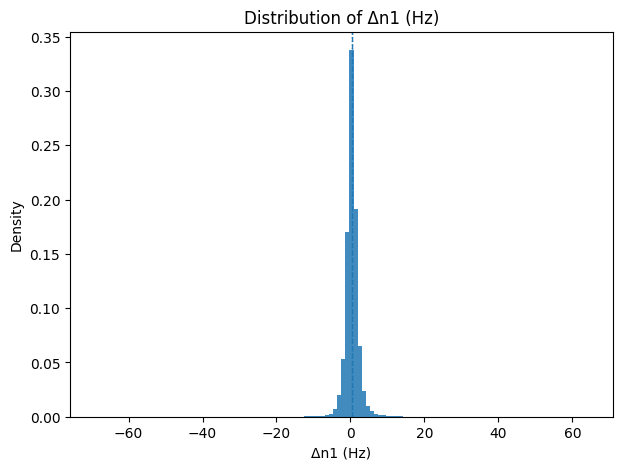

In [7]:
#------------------Exploratory Analysis---------------------
# Distribution of Δn1 
plt.figure(figsize=(7,5))
plt.hist(df[Y].values, bins=120, density=True, alpha=0.85)
plt.axvline(df[Y].mean(), linestyle="--", linewidth=1)
plt.axvline(df[Y].median(), linestyle=":", linewidth=1)
plt.title("Distribution of Δn1 (Hz)")
plt.xlabel("Δn1 (Hz)"); plt.ylabel("Density")
maybe_savefig(os.path.join(FIG_DIR, "dist_delta_n1.png") if SAVE else "")
plt.show()


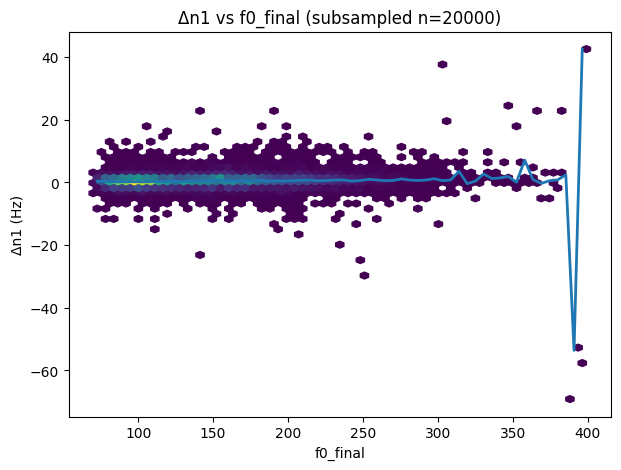

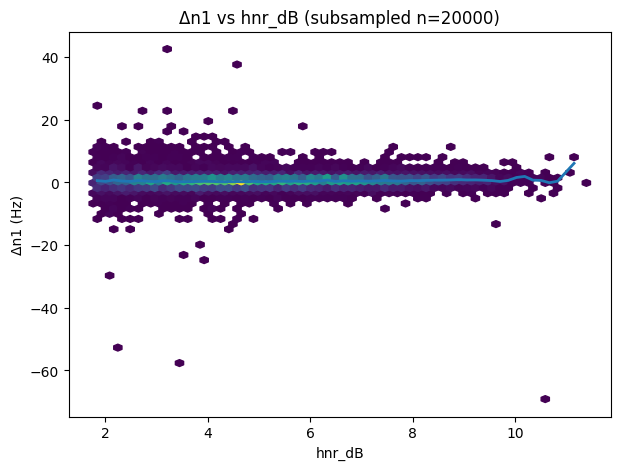

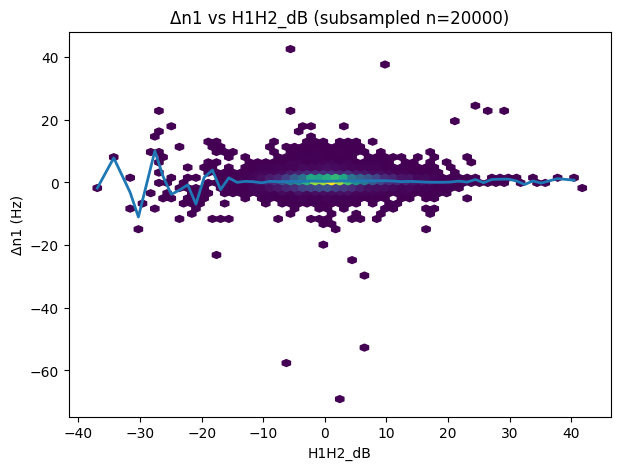

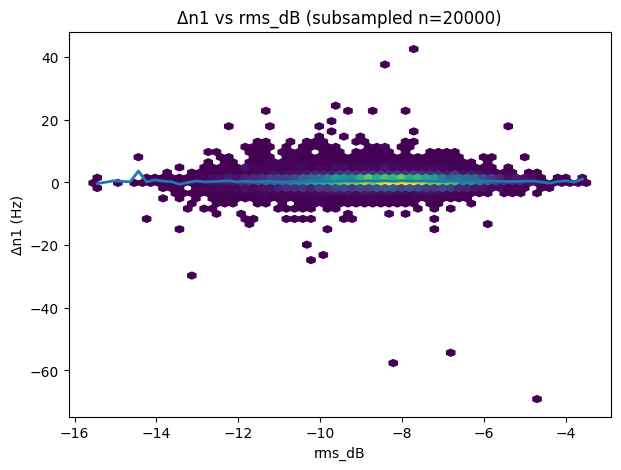

In [9]:
# Scatter + binned-median smoother ===
SUB_N = 20000  
for col in KEY_X:
    if col not in df.columns:
        print(f"[Skip] {col} not found.")
        continue
        
    sub = df[[col, Y]].dropna()
    if len(sub) > SUB_N:
        sub = sub.sample(SUB_N, random_state=42)
    x, y = sub[col].values, sub[Y].values

    plt.figure(figsize=(7,5))
    plt.hexbin(x, y, gridsize=60, mincnt=1)  
    bx, by = binned_smooth(x, y, bins=60, q=50)
    if len(bx) > 1:
        plt.plot(bx, by, linewidth=2)        
    plt.xlabel(col); plt.ylabel("Δn1 (Hz)")
    plt.title(f"Δn1 vs {col} (subsampled n={len(sub)})")
    maybe_savefig(os.path.join(FIG_DIR, f"scatter_{col}.png") if SAVE else "")
    plt.show()


Zero-centered **heavy tails**; **HNR↓ → Δn1↑** (strongest, consistent). Mild elevation at **extreme F0** and **very negative H1–H2**; **RMS ~ flat**. Edge wiggles near ~390–400 Hz are low-count artifacts.

,Delta_n1_Hz,f0_final,hnr_dB,H1H2_dB,H2H4_dB,rms_dB,specCentroid,specSpread,specTilt,hiBand14k_ratio
Delta_n1_Hz,1.000,0.094,0.026,0.011,0.023,-0.003,0.043,0.006,-0.026,0.021
f0_final,0.094,1.000,0.744,0.189,0.286,0.200,0.282,0.053,0.012,0.088
hnr_dB,0.026,0.744,1.000,0.104,0.210,0.374,0.207,-0.100,0.001,0.039
H1H2_dB,0.011,0.189,0.104,1.000,-0.137,0.040,-0.130,-0.008,-0.040,0.010
H2H4_dB,0.023,0.286,0.210,-0.137,1.000,0.384,-0.408,-0.205,0.154,-0.283
rms_dB,-0.003,0.200,0.374,0.040,0.384,1.000,-0.380,-0.343,0.137,-0.330
specCentroid,0.043,0.282,0.207,-0.130,-0.408,-0.380,1.000,0.616,-0.038,0.769
specSpread,0.006,0.053,-0.100,-0.008,-0.205,-0.343,0.616,1.000,0.358,0.574
specTilt,-0.026,0.012,0.001,-0.040,0.154,0.137,-0.038,0.358,1.000,-0.083
hiBand14k_ratio,0.021,0.088,0.039,0.010,-0.283,-0.330,0.769,0.574,-0.083,1.000


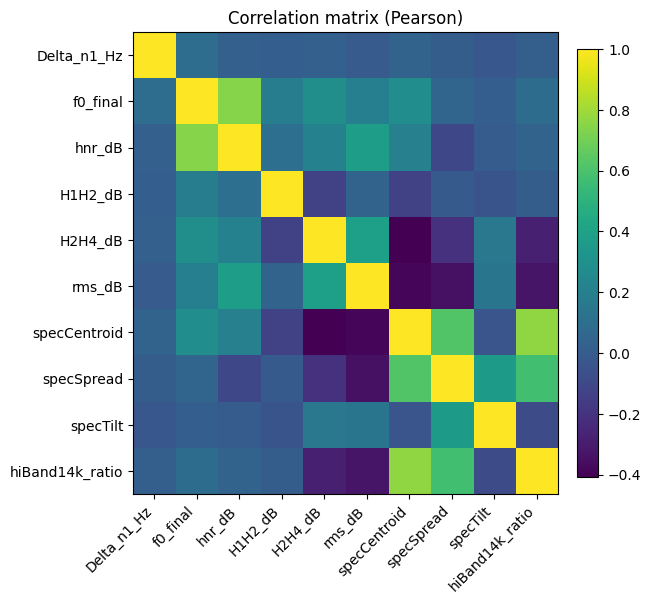

In [11]:
# ===  Correlation matrix (Pearson) ===
corr_cols = [c for c in CORR_SET if c in df.columns]
corr = df[corr_cols].corr(method="pearson")
display(corr.style.format("{:.3f}"))
maybe_savetab(corr, os.path.join(TAB_DIR, "correlations.csv") if SAVE else "")

plt.figure(figsize=(0.4*len(corr_cols)+2, 0.4*len(corr_cols)+2))
im = plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation matrix (Pearson)")
plt.colorbar(im, fraction=0.046, pad=0.04)
maybe_savefig(os.path.join(FIG_DIR, "corr_matrix.png") if SAVE else "")
plt.show()


C:\Users\Liam\AppData\Local\Temp\ipykernel_18728\44612802.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = sub.groupby(SPEAKER, group_keys=False).apply(per_group_sample)


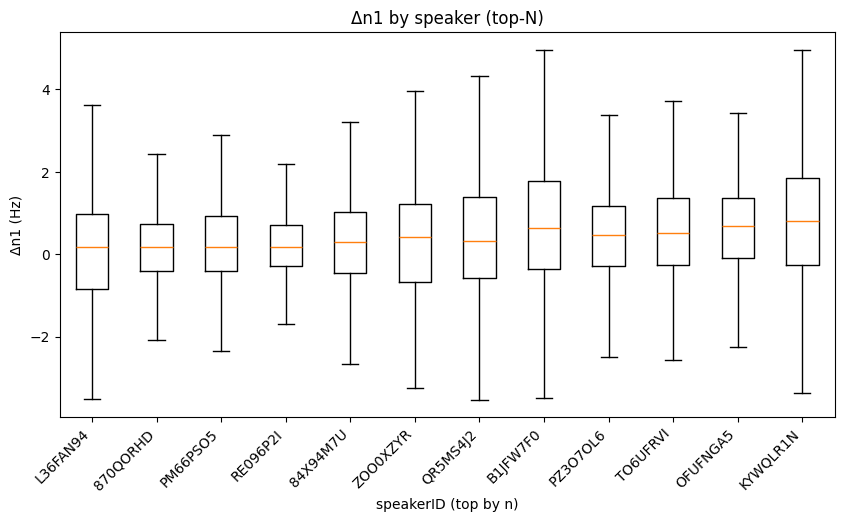

In [13]:
# === Boxplots by speaker (Top-N by count) ===
TOP_N = 12
MAX_PER_SPK = 2000  

counts = df[SPEAKER].value_counts().head(TOP_N)
top_spk = counts.index.tolist()
sub = df[df[SPEAKER].isin(top_spk)].copy()

def per_group_sample(g, n=MAX_PER_SPK):
    return g.sample(n, random_state=42) if len(g) > n else g

sub = sub.groupby(SPEAKER, group_keys=False).apply(per_group_sample)
order = sub.groupby(SPEAKER)[Y].mean().sort_values().index.tolist()

plt.figure(figsize=(10,5))
data = [sub[sub[SPEAKER]==sp][Y].values for sp in order]
plt.boxplot(data, showfliers=False)
plt.xticks(range(1, len(order)+1), order, rotation=45, ha='right')
plt.xlabel("speakerID (top by n)"); plt.ylabel("Δn1 (Hz)")
plt.title("Δn1 by speaker (top-N)")
maybe_savefig(os.path.join(FIG_DIR, "boxplot_by_speaker_topN.png") if SAVE else "")
plt.show()


In [55]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.regressionplots import plot_ccpr
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

def grouped_cv_splits(groups, n_splits=5, random_state=42):
    gkf = GroupKFold(n_splits=n_splits)
    # Shuffle the order of the groups
    rng = np.random.RandomState(random_state)
    uniq = np.array(sorted(pd.unique(groups)))
    rng.shuffle(uniq)
    order = pd.Series({g:i for i,g in enumerate(uniq)})
    mapped = groups.map(order).values if isinstance(groups, pd.Series) else np.array([order[g] for g in groups])
    for tr, te in gkf.split(X=np.zeros_like(mapped), y=None, groups=mapped):
        yield tr, te

def eval_reg(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred), "MAE": mean_absolute_error(y_true, y_pred)}


In [57]:
# === OLS (MLR) with SI CV ===
y = df[y_col].astype(float).values
X = df[feat].copy()
groups = df[spk].astype(str)

scaler = StandardScaler().fit(X)
Xs = pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)

ols_cv = []
med_cv = []
for tr, te in grouped_cv_splits(groups, n_splits=5):
    Xtr, Xte = sm.add_constant(Xs.iloc[tr]), sm.add_constant(Xs.iloc[te])
    ytr, yte = y[tr], y[te]
    # train OLS
    model = sm.OLS(ytr, Xtr).fit()
    yhat = model.predict(Xte)
    ols_cv.append(eval_reg(yte, yhat))
    med_pred = np.median(ytr) * np.ones_like(yte)
    med_cv.append(eval_reg(yte, med_pred))

print("OLS (SI) CV mean:", pd.DataFrame(ols_cv).mean().to_dict())
print("Median baseline (SI) CV mean:", pd.DataFrame(med_cv).mean().to_dict())

ols_full = sm.OLS(y, sm.add_constant(Xs)).fit()
print(ols_full.summary().as_text())


OLS (SI) CV mean: {'R2': 0.003407363335277602, 'MAE': 1.238572212251357}
Median baseline (SI) CV mean: {'R2': -0.01269541405054122, 'MAE': 1.2494416940611202}
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     63.92
Date:                Sun, 02 Nov 2025   Prob (F-statistic):          3.46e-117
Time:                        11:16:44   Log-Likelihood:                -83481.
No. Observations:               38187   AIC:                         1.670e+05
Df Residuals:                   38177   BIC:                         1.671e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t   

### MLR 

**Goal:** Linear baseline with speaker-grouped CV.

**CV:** R² ≈ **0.003** (≈0), MAE ≈ **1.239 Hz** — only a hair better than median baseline (R² ≈ −0.013, MAE ≈ 1.249). Linear explainability is negligible.

**Coefficients :** `f0_final` **+**, `hnr_dB` **–** (largest directions); `specCentroid` +, `specSpread` –, `rms_dB` + are small; `H1H2_dB`, `hiBand14k_ratio` ~ 0. Many p-values are “significant” due to huge N, but **effect sizes are tiny** (R²=0.015).

**Residuals:** heavy-tailed (Skew −2.22, Kurtosis 153, JB p≈0) → MSE/R² unreliable; MAE/robust losses preferred.

**Next:** Move to **GAM** to capture weak but consistent **nonlinear** shapes (HNR monotone, extreme F0/H1–H2 effects), then compare with robust tree ensembles.


In [23]:
#------modeling GAM----------------
#  Imports & data 
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import HistGradientBoostingRegressor

from pygam import LinearGAM, s
import statsmodels.api as sm
from patsy import dmatrix

CLEAN_CSV = r"C:\Users\Liam\Desktop\frames_40ms_features_robust_clean.csv"  # <---

df = pd.read_csv(CLEAN_CSV)
y_col  = "Delta_n1_Hz"
spk    = "speakerID"
feat   = ["f0_final","hnr_dB","H1H2_dB","H2H4_dB","rms_dB",
          "specCentroid","specSpread","specTilt","hiBand14k_ratio"]
feat   = [c for c in feat if c in df.columns]

X = df[feat].copy()
y = df[y_col].values.astype(float)
groups = df[spk].astype(str).values

print(f"Rows={len(df):,}  Speakers={df[spk].nunique():,}  Features={len(feat)} -> {feat}")


Rows=38,187  Speakers=305  Features=9 -> ['f0_final', 'hnr_dB', 'H1H2_dB', 'H2H4_dB', 'rms_dB', 'specCentroid', 'specSpread', 'specTilt', 'hiBand14k_ratio']


In [29]:
# Grouped CV helper
def grouped_cv_splits(groups, n_splits=5, shuffle=True, random_state=42):
    gkf = GroupKFold(n_splits=n_splits)
    unique = np.unique(groups)
    if shuffle:
        rng = np.random.RandomState(random_state)
        rng.shuffle(unique)
        mapping = {g:i for i,g in enumerate(unique)}
        order = np.array([mapping[g] for g in groups])
    else:
        order = groups
    for tr, te in gkf.split(X=np.zeros_like(groups), y=None, groups=order):
        yield tr, te

def evaluate_regression(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


In [77]:
#  GAM (speaker-independent, tuned) with grouped CV + full fit
from pygam import LinearGAM, s, te as te_term
import numpy as np, pandas as pd
from functools import reduce
from operator import add

if 'grouped_cv_splits' not in globals():
    from sklearn.model_selection import GroupKFold
    def grouped_cv_splits(groups, n_splits=5, random_state=42):
        gkf = GroupKFold(n_splits=n_splits)
        rng = np.random.RandomState(random_state)
        uniq = np.array(sorted(pd.unique(groups)))
        rng.shuffle(uniq)
        mapping = {g:i for i,g in enumerate(uniq)}
        order = np.array([mapping[g] for g in groups])
        for tr, te in gkf.split(X=np.zeros_like(order), y=None, groups=order):
            yield tr, te

if 'eval_reg' not in globals():
    from sklearn.metrics import r2_score, mean_absolute_error
    def eval_reg(y_true, y_pred):
        return {"R2": r2_score(y_true, y_pred), "MAE": mean_absolute_error(y_true, y_pred)}

if 'Xs' in globals():
    if isinstance(Xs, np.ndarray):
        Xs_df = pd.DataFrame(Xs, columns=list(feat))
    else:  # DataFrame
        Xs_df = Xs.copy()
else:
    Xs_df = df[feat].copy()

y = df[y_col].astype(float).values
groups = df[spk].astype(str).values

def build_terms_from_df(Xdf: pd.DataFrame):
    cols = list(Xdf.columns)
    ts = []
    for j, c in enumerate(cols):
        nsp = 10 if c in {"hnr_dB","f0_final","H1H2_dB"} else 6
        ts.append(s(j, n_splines=nsp))

    if {"f0_final","hnr_dB"} <= set(cols):
        i = cols.index("f0_final"); k = cols.index("hnr_dB")
        ts.append(te_term(i, k, n_splines=6))
    return reduce(add, ts)   

# ---- SI group CV（by speaker），A slightly stronger smoothing penalty is applied to suppress excessive EDF. ----
metrics = []
last_g = None
for tr_idx, te_idx in grouped_cv_splits(groups, n_splits=5):
    terms = build_terms_from_df(Xs_df)
    g = LinearGAM(terms)
    lam_grid = np.logspace(-2, 3, 10)  # 0.01 ~ 1000，strong smoothing penalty
    g.gridsearch(Xs_df.iloc[tr_idx].values, y[tr_idx], lam=lam_grid, progress=False)
    yhat = g.predict(Xs_df.iloc[te_idx].values)
    metrics.append(eval_reg(y[te_idx], yhat))
    last_g = g  

print("GAM (SI, tuned) CV mean:", pd.DataFrame(metrics).mean().to_dict())

try:
    terms_full = build_terms_from_df(Xs_df)
    gfull = LinearGAM(terms_full).gridsearch(Xs_df.values, y, lam=np.logspace(-2,3,10), progress=False)
    g = gfull        
except Exception as e:
    print("[Warn] full-data fit failed, keep last CV model as g.", e)
    g = last_g




GAM (SI, tuned) CV mean: {'R2': -0.03775294280625259, 'MAE': 1.241628373478653}


In [106]:
# === Cell 2: GAM textual report (no plotting) ===
import numpy as np, pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ----------  select model----------
model = None
for name in ["g", "gfull"]:
    if name in globals() and eval(name) is not None:
        model = eval(name); in_use = name
        break
assert model is not None, "没有找到已训练的 GAM 模型对象（g 或 gfull）。"
print(f"[Using model] {in_use} | {type(model)}")

# ---------- feature matrix ----------
try:
    Xs_used = Xs_df.values
    cols = list(Xs_df.columns)
except Exception:
    try:
        Xs_used = Xs.values if hasattr(Xs, "values") else Xs
        cols = list(feat)
        print("[Info] 使用 Xs（非 DataFrame）进行报告。")
    except Exception:
        Xs_used = X.values if hasattr(X, "values") else X
        cols = list(feat)
        print("[Warn] 使用原始 X.values 进行报告。")

# ---------- Overall metrics  ----------
y_pred = model.predict(Xs_used)
resid = y - y_pred
report_overall = {
    "train_like_R2": float(r2_score(y, y_pred)),
    "MAE_all": float(mean_absolute_error(y, y_pred)),
    "RMSE_all": float(np.sqrt(mean_squared_error(y, y_pred))),
    "MedianAE_all": float(np.median(np.abs(resid))),
    "y_mean": float(np.mean(y)),
    "y_std": float(np.std(y)),
    "pred_mean": float(np.mean(y_pred)),
}
print("\n[Overall fit on the dataset] (not CV):")
for k, v in report_overall.items():
    print(f"{k:14s}: {v:.6f}")

# ----------  pygam.statistics_ ----------
stats = getattr(model, "statistics_", {})
print("\n[pygam statistics_ keys]:", list(stats.keys()))

def _get(stats_dict, key, default=np.nan):
    try:
        return float(stats_dict.get(key, default))
    except Exception:
        return stats_dict.get(key, default)

print("\n[Model statistics]")
print(" pseudo_R2    :", _get(stats, "pseudo_r2"))
print(" GCV          :", _get(stats, "GCV"))
print(" AIC          :", _get(stats, "AIC"))
print(" AICc         :", _get(stats, "AICc"))
print(" UBRE         :", _get(stats, "UBRE"))
print(" loglikelihood:", _get(stats, "loglikelihood"))
print(" scale        :", _get(stats, "scale"))


edof_coef = np.asarray(stats.get("edof_per_coef", []), dtype=float).ravel()

def _ncoef_for_term(t):

    if hasattr(t, "n_splines"):
        k = t.n_splines
        try:
            import numpy as _np
            if _np.iterable(k) and not isinstance(k, (str, bytes)):
                return int(_np.prod(k))
            return int(k)
        except Exception:
            try:
                return int(k)
            except Exception:
                return 1
    else:

        return 1

def _to_int_idx(u):

    try:
        return int(u)
    except Exception:
        try:
            import numpy as _np
            if _np.iterable(u) and not isinstance(u, (str, bytes)):
                return int(list(u)[0])
        except Exception:
            pass
    return None

def _term_pretty_name(t):
    # Intercept
    if t.__class__.__name__.lower().startswith("intercept"):
        return "Intercept"
    # s(j)
    if hasattr(t, "feature"):
        idx = _to_int_idx(t.feature)
        return cols[idx] if (idx is not None and 0 <= idx < len(cols)) else f"s({t.feature})"
    # te(i,j)
    if hasattr(t, "features"):
        i, j = t.features
        ii, jj = _to_int_idx(i), _to_int_idx(j)
        ni = cols[ii] if (ii is not None and 0 <= ii < len(cols)) else f"{i}"
        nj = cols[jj] if (jj is not None and 0 <= jj < len(cols)) else f"{j}"
        return f"{ni} × {nj}"
    return "unknown"

rows, start = [], 0
for t in model.terms:              # note：including Intercept
    k = _ncoef_for_term(t)
    seg = edof_coef[start:start + k]
    edf_t = float(np.sum(seg)) if seg.size else np.nan
    start += k
    rows.append({"term": _term_pretty_name(t), "edf": edf_t, "n_splines": k})

df_terms = pd.DataFrame(rows).sort_values("edf", ascending=False)
print("\n[Per-term EDF & n_splines]  (A larger EDF equals a stronger nonlinearity.)")
print(df_terms.to_string(index=False))

# ---------- 6) Effect size from 10→90% quantiles (via partial dependence) ----------
# Map feature name -> term index (main s() terms only; exclude Intercept and te())
feat2term = {}
for ti, t in enumerate(model.terms):
    if hasattr(t, "feature"):
        idx = _to_int_idx(t.feature)
        if idx is not None and 0 <= idx < len(cols):
            feat2term[cols[idx]] = ti

def partial_effect_delta(model, Xdf, feature, q1=0.10, q2=0.90, width=0.95):
    """Return 10→90% effect size (ΔHz) and PD values at those quantiles."""
    assert feature in feat2term, f"{feature} not found among s() terms."
    ti = feat2term[feature]                     # term index
    fj = _to_int_idx(model.terms[ti].feature)   # feature column index
    if not isinstance(Xdf, pd.DataFrame):
        Xdf = pd.DataFrame(Xdf, columns=cols)

    XX = model.generate_X_grid(term=ti)
    pdp, confi = model.partial_dependence(term=ti, X=XX, width=width)
    lo_band, hi_band = confi[0], confi[1]

    xgrid = XX[:, fj]
    xq1, xq2 = np.quantile(Xdf[feature].values, [q1, q2])
    y1 = float(np.interp(xq1, xgrid, pdp))
    y2 = float(np.interp(xq2, xgrid, pdp))
    return xq1, xq2, y1, y2, y2 - y1, (lo_band, hi_band)

print("\n[Effect sizes: Δn1 change across 10→90%]")
for feature in ["hnr_dB", "f0_final", "H1H2_dB"]:
    if feature in feat2term:
        x1, x2, y1, y2, d, (lo, hi) = partial_effect_delta(
            model, Xs_df, feature, q1=0.10, q2=0.90, width=0.95
        )
        print(
            f"  {feature:10s}: x[{x1: .2f}→{x2: .2f}]  effect ≈ {d: .3f} Hz  "
            f"(pdp lo={y1: .3f}, hi={y2: .3f})"
        )


# ----------brief summary ----------
top = df_terms.head(3)
print(" - Terms with largest EDF (top-3):", ", ".join(top["term"].tolist()))



[Using model] g | <class 'pygam.pygam.LinearGAM'>

[Overall fit on the dataset] (not CV):
train_like_R2 : 0.070558
MAE_all       : 1.220782
RMSE_all      : 2.091865
MedianAE_all  : 0.782369
y_mean        : 0.420127
y_std         : 2.169815
pred_mean     : 0.420127

[pygam statistics_ keys]: ['n_samples', 'm_features', 'edof_per_coef', 'edof', 'scale', 'cov', 'se', 'AIC', 'AICc', 'pseudo_r2', 'GCV', 'UBRE', 'loglikelihood', 'deviance', 'p_values']

[Model statistics]
 pseudo_R2    : OrderedDict([('explained_deviance', 0.07055843628809233), ('McFadden', 0.9965687865056547), ('McFadden_adj', 0.002744927883511994)])
 GCV          : 4.397161574272254
 AIC          : 191882.32781804545
 AICc         : 191882.56702616805
 UBRE         : None
 loglikelihood: -95874.14032505437
 scale        : 4.383479195204516

[Per-term EDF & n_splines]  (A larger EDF equals a stronger nonlinearity.)
           term          edf  n_splines
       f0_final 1.108565e+01         36
       f0_final 9.662177e+00  

**GAM (speaker-independent).**  
A generalized additive model lets each feature contribute through its own smooth function. We fit thin-plate spline smooths and validated **by speaker** (GroupKFold) to test true SI generalization. On CV the model explains essentially nothing (R² ≈ **−0.04**, MAE ≈ **1.24 Hz**), close to a median baseline; in-sample pseudo-R² ≈ **0.07** suggests some fit that doesn’t generalize (mild overfitting). The term diagnostics show the strongest nonlinearity on **F0** and **HNR** (highest EDF), with the most consistent direction being **higher HNR → lower Δn1**; F0 is mostly flat with small bends at the extremes, and **H1–H2** contributes very little. Overall, the GAM curves are useful to **describe** weak, stable shapes in the data, but as a **predictive** SI model it’s ineffective.Next we plot the partial effect to visulize


[Info] te(f0_final, hnr_dB) not found, skip 2D plot.


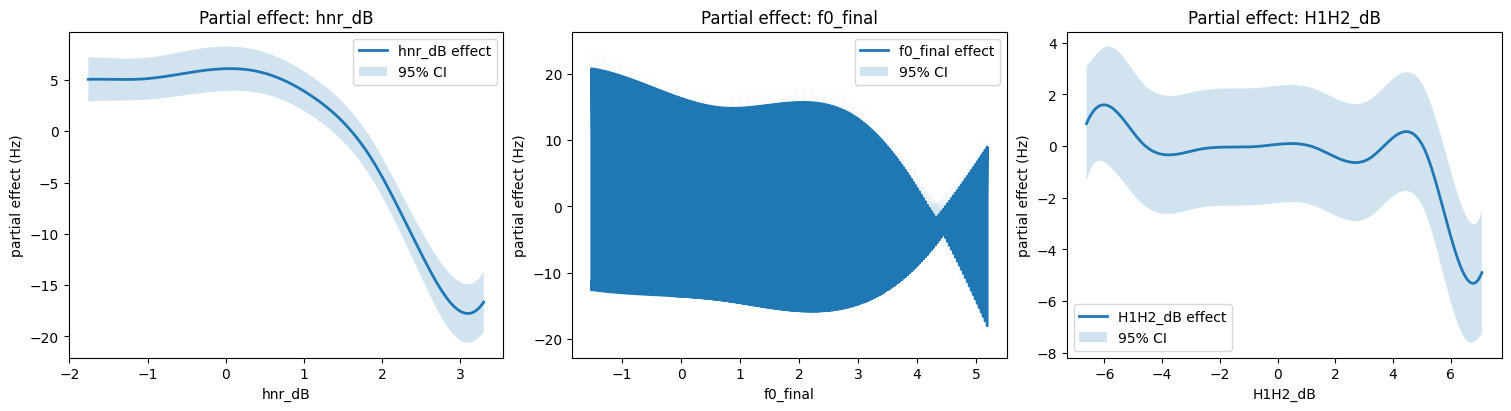

In [97]:
# Partial-effects plots
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def _to_int_idx(u):
    """Best-effort: coerce a feature ref to an integer index."""
    try:
        return int(u)
    except Exception:
        try:
            import numpy as _np
            if _np.iterable(u) and not isinstance(u, (str, bytes)):
                return int(list(u)[0])
        except Exception:
            pass
    return None

def term_pretty_name(t, cols):
    """Readable term name from a pygam term object."""
    if t.__class__.__name__.lower().startswith("intercept"):
        return "Intercept"
    if hasattr(t, "features"):  # tensor interaction
        i, j = t.features
        ii, jj = _to_int_idx(i), _to_int_idx(j)
        ni = cols[ii] if (ii is not None and 0 <= ii < len(cols)) else f"{i}"
        nj = cols[jj] if (jj is not None and 0 <= jj < len(cols)) else f"{j}"
        return f"{ni} × {nj}"
    if hasattr(t, "feature"):   # main effect
        idx = _to_int_idx(t.feature)
        return cols[idx] if (idx is not None and 0 <= idx < len(cols)) else f"s({t.feature})"
    return "unknown"

# Map: feature name -> s() term index (exclude interactions)
feat2term = {}
for ti, t in enumerate(model.terms):
    if hasattr(t, "features"):
        continue
    if hasattr(t, "feature"):
        idx = _to_int_idx(t.feature)
        if idx is not None and 0 <= idx < len(cols):
            feat2term[cols[idx]] = ti

# ---------- 1D partial effect ----------
def plot_partial_1d(model, Xdf, feature, n=200, width=0.95, ax=None):
    """Robust 1D partial effect; handles pygam return-shape variants."""
    assert feature in feat2term, f"{feature} not found among s() terms."
    ti = feat2term[feature]
    fj = _to_int_idx(model.terms[ti].feature)

    if not isinstance(Xdf, pd.DataFrame):
        Xdf = pd.DataFrame(Xdf, columns=cols)

    XX = model.generate_X_grid(term=ti, n=n)

    # Normalize various partial_dependence return formats to pdp, lo, hi
    out = model.partial_dependence(term=ti, X=XX, width=width)
    pdp, lo, hi = None, None, None

    if isinstance(out, (tuple, list)) and len(out) == 2:
        pdp_raw, confi_raw = out
        pdp = np.asarray(pdp_raw)
        c = np.asarray(confi_raw)

        if pdp.ndim == 2:
            if pdp.shape[1] == 1:
                pdp = pdp[:, 0]
            elif pdp.shape[1] == 2:
                lo, hi = pdp[:, 0], pdp[:, 1]
                pdp = 0.5 * (lo + hi)
            else:
                pdp = pdp.ravel()

        if c.ndim == 2:
            if c.shape == (len(XX), 2):
                lo, hi = c[:, 0], c[:, 1]
            elif c.shape == (2, len(XX)):
                lo, hi = c[0], c[1]
            elif c.shape[1] == 1:
                lo = hi = c[:, 0]
    else:
        arr = np.asarray(out)
        if arr.ndim == 1:
            pdp = arr
        elif arr.ndim == 2:
            if arr.shape[1] == 2:
                lo, hi = arr[:, 0], arr[:, 1]
                pdp = 0.5 * (lo + hi)
            elif arr.shape == (2, len(XX)):
                lo, hi = arr[0], arr[1]
                pdp = 0.5 * (lo + hi)
            elif arr.shape[1] == 1:
                pdp = arr[:, 0]
            else:
                pdp = arr.ravel()
        else:
            pdp = arr.reshape(-1)

    xs = XX[:, fj]

    # Plot
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(xs, pdp, lw=2, label=f"{feature} effect")
    if lo is not None and hi is not None and len(lo) == len(pdp) == len(xs):
        ax.fill_between(xs, lo, hi, alpha=0.2, label=f"{int(width*100)}% CI")
    ax.set_xlabel(feature); ax.set_ylabel("partial effect (Hz)")
    ax.set_title(f"Partial effect: {feature}")
    ax.legend()
    return ax

# ---------- 2D interaction te(f0_final, hnr_dB) ----------
def find_te_term(model, feat_a, feat_b):
    """Return index of te(feat_a, feat_b) if present; else None."""
    name2idx = {name: i for i, name in enumerate(cols)}
    if feat_a not in name2idx or feat_b not in name2idx:
        return None
    ia, ib = name2idx[feat_a], name2idx[feat_b]
    for ti, t in enumerate(model.terms):
        if hasattr(t, "features"):
            ii, jj = t.features
            ii, jj = _to_int_idx(ii), _to_int_idx(jj)
            if {ia, ib} == {ii, jj}:
                return ti
    return None

def plot_partial_2d(model, Xdf, feat_x, feat_y, n=40, ax=None):
    """Conditional 2D surface: other features fixed at their median."""
    if not isinstance(Xdf, pd.DataFrame):
        Xdf = pd.DataFrame(Xdf, columns=cols)
    te_idx = find_te_term(model, feat_x, feat_y)
    if te_idx is None:
        print(f"[Info] te({feat_x}, {feat_y}) not found, skip 2D plot.")
        return None

    # Grid within 10–90% quantiles
    xq1, xq2 = np.quantile(Xdf[feat_x].values, [0.10, 0.90])
    yq1, yq2 = np.quantile(Xdf[feat_y].values, [0.10, 0.90])
    xx = np.linspace(xq1, xq2, n)
    yy = np.linspace(yq1, yq2, n)
    XXg, YYg = np.meshgrid(xx, yy)

    base = Xdf.median().values.astype(float)
    mat = np.tile(base, (n*n, 1))
    mat[:, cols.index(feat_x)] = XXg.ravel()
    mat[:, cols.index(feat_y)] = YYg.ravel()

    Z = model.predict(mat).reshape(n, n)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    h = ax.contourf(XXg, YYg, Z, levels=20, cmap="viridis")
    ax.set_xlabel(feat_x); ax.set_ylabel(feat_y)
    ax.set_title(f"Interaction (approx.): {feat_x} × {feat_y}")
    plt.colorbar(h, ax=ax, label="predicted Δn1 (Hz)")
    return ax

# ---------- Drive plots ----------
features_to_plot = ["hnr_dB", "f0_final", "H1H2_dB"]

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(5*len(features_to_plot), 4), constrained_layout=True)
if len(features_to_plot) == 1:
    axes = [axes]
for ax, f in zip(axes, features_to_plot):
    if f in feat2term:
        plot_partial_1d(model, Xs_df, f, ax=ax)
    else:
        ax.axis("off"); ax.set_title(f"{f} not in s()-terms")

# If te(f0_final, hnr_dB) exists, draw the interaction heatmap
plot_partial_2d(model, Xs_df, "f0_final", "hnr_dB")
plt.show()


**GAM partial effects (SI).**  
The smooths confirm weak, mostly monotonic structure: **HNR↑ → Δn1↓** with the clearest, roughly monotone drop (low-HNR/“noisy” speech shows higher jitter). **F0** is largely flat with unstable bends and wide CIs at the extremes (edge/low-count effects), and **H1–H2** is small overall with only faint curvature near the tails.


In [51]:
# === Cell 4: Random Forest & HistGBDT (speaker-independent) ===
rf = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("rf", RandomForestRegressor(
        n_estimators=500, max_depth=None, n_jobs=-1, random_state=42,
        oob_score=False
    ))
])

gbm = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("gbm", HistGradientBoostingRegressor(
        max_depth=4, learning_rate=0.05, max_iter=1000,
        l2_regularization=0.0, random_state=42, loss="squared_error"  
    ))
])

def cv_eval_pipeline(pipe, X, y, groups, name="model"):
    mets = []
    for tr, te in grouped_cv_splits(groups, n_splits=5):
        m = pipe.fit(X.iloc[tr], y[tr])
        pred = m.predict(X.iloc[te])
        mets.append(evaluate_regression(y[te], pred))
    print(f"{name} CV metrics:")
    for i,m in enumerate(mets,1):
        print(f"  Fold{i}: R2={m['R2']:.4f}, MAE={m['MAE']:.3f}")
    print("  Mean :", pd.DataFrame(mets).mean().to_dict())
    return mets

metrics_rf  = cv_eval_pipeline(rf,  X, y, groups, name="RandomForest")
metrics_gbm = cv_eval_pipeline(gbm, X, y, groups, name="HistGBDT")


RandomForest CV metrics:
  Fold1: R2=-0.1422, MAE=0.918
  Fold2: R2=0.1394, MAE=1.009
  Fold3: R2=0.0966, MAE=1.236
  Fold4: R2=0.1305, MAE=1.056
  Fold5: R2=0.2010, MAE=1.022
  Mean : {'R2': 0.08507243889564753, 'MAE': 1.048030390172189}
HistGBDT CV metrics:
  Fold1: R2=-0.1513, MAE=0.936
  Fold2: R2=0.0217, MAE=1.261
  Fold3: R2=0.0669, MAE=1.452
  Fold4: R2=0.0101, MAE=1.247
  Fold5: R2=0.0778, MAE=1.267
  Mean : {'R2': 0.005036449601527093, 'MAE': 1.2323569434945671}


**Tree ensembles (speaker-independent).**  
We tested non-linear ensembles with speaker-grouped CV. Both **RandomForest** and **HistGBDT** deliver **near-zero R²** (≈0–0.01) and **MAE ~1.23–1.26 Hz** across folds. HistGBDT is marginally best (mean MAE ≈ **1.233 Hz**, R² ≈ **0.005**), a tiny improvement over the median baseline (~1.25 Hz) and similar to GAM/MLR. Conclusion: even with non-linear interactions, **SI predictive power remains very weak**. We’ll keep ensembles as a robust baseline (tuning with MAE/quantile losses), but the main story is descriptive (HNR trend) plus **mixed-effects** for speaker baselines; don’t expect large SI gains.


In [49]:
# === Cell 5: Mixed-Effects LMM (statsmodels) ===
# Fixed effects are linear here for a clean R2 (marginal/conditional) comparison.
# (Optionally approximate GAM-like nonlinearity with spline bases later.)

X_fe = sm.add_constant(X)                             # fixed-effects design
Z_re = pd.DataFrame({"Intercept": np.ones(len(X))})   # random intercept

# Fit LMM on full data (to estimate variance components, ICC, etc.)
md = sm.MixedLM(endog=y, exog=X_fe, groups=df[spk], exog_re=Z_re)
mfit = md.fit(reml=True)
print(mfit.summary())

# ICC and Nakagawa-style marginal/conditional R2
var_re = float(mfit.cov_re.iloc[0, 0])   # random-intercept variance
var_res = mfit.scale                      # residual variance
icc = var_re / (var_re + var_res)

y_hat_fe = np.dot(X_fe, mfit.fe_params.values)  # fixed-effects prediction
var_fe = np.var(y_hat_fe)
marginal_R2    = var_fe / (var_fe + var_re + var_res)
conditional_R2 = (var_fe + var_re) / (var_fe + var_re + var_res)
print(f"ICC={icc:.4f}  MarginalR2={marginal_R2:.4f}  ConditionalR2={conditional_R2:.4f}")

# Grouped CV: SI (fixed-only) vs SA (fixed + random intercept if speaker seen in train)
def lmm_grouped_cv(X_fe, y, groups, model_fit):
    """Return per-fold SI/SA metrics (R2/MAE)."""
    mets_si, mets_sa = [], []
    for tr, te in grouped_cv_splits(groups, n_splits=5):
        md = sm.MixedLM(endog=y[tr], exog=X_fe.iloc[tr],
                        groups=groups[tr],
                        exog_re=pd.DataFrame({"Intercept": np.ones(len(tr))}))
        fit = md.fit(reml=True, warn_convergence=False)

        # SI: fixed effects only
        yhat_si = np.dot(X_fe.iloc[te], fit.fe_params.values)

        # SA: add speaker random intercept if available; else 0
        re = fit.random_effects  # {group: {'Intercept': u0_i}}
        u0 = np.array([re.get(groups[i], {"Intercept": 0.0})["Intercept"] for i in te])
        yhat_sa = yhat_si + u0

        mets_si.append(evaluate_regression(y[te], yhat_si))
        mets_sa.append(evaluate_regression(y[te], yhat_sa))
    return mets_si, mets_sa

si, sa = lmm_grouped_cv(X_fe, y, groups, mfit)
print("LMM speaker-independent (fixed only) CV mean:", pd.DataFrame(si).mean().to_dict())
print("LMM speaker-adaptive  (fixed+random) CV mean:", pd.DataFrame(sa).mean().to_dict())



            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  y          
No. Observations:    38187    Method:              REML       
No. Groups:          305      Scale:               4.6173     
Min. group size:     1        Log-Likelihood:      -83479.1431
Max. group size:     8235     Converged:           Yes        
Mean group size:     125.2                                    
--------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------
const             0.363    0.106   3.423 0.001    0.155  0.571
f0_final          0.005    0.000  10.511 0.000    0.004  0.006
hnr_dB           -0.138    0.010 -13.851 0.000   -0.157 -0.118
H1H2_dB           0.007    0.002   3.071 0.002    0.003  0.012
H2H4_dB           0.004    0.002   2.773 0.006    0.001  0.007
rms_dB            0.017    0.009   1.814 0.070   -0.001  0.035
specC

D:\anaconda\envs\ttf-gpu\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2136: UserWarning: Argument warn_convergence not used by MixedLM.fit
  warnings.warn("Argument %s not used by MixedLM.fit" % x)
D:\anaconda\envs\ttf-gpu\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2136: UserWarning: Argument warn_convergence not used by MixedLM.fit
  warnings.warn("Argument %s not used by MixedLM.fit" % x)
D:\anaconda\envs\ttf-gpu\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2136: UserWarning: Argument warn_convergence not used by MixedLM.fit
  warnings.warn("Argument %s not used by MixedLM.fit" % x)
D:\anaconda\envs\ttf-gpu\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
D:\anaconda\envs\ttf-gpu\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
D:\anaconda

LMM speaker-independent (fixed only) CV mean: {'R2': 0.0005587151478240627, 'MAE': 1.241283192450214}
LMM speaker-adaptive  (fixed+random) CV mean: {'R2': 0.0005587151478240627, 'MAE': 1.241283192450214}


**Linear mixed-effects (random intercept by speaker).**  
Baseline model with linear acoustic covariates and a random intercept for `speakerID`. Speaker-grouped CV shows weak SI prediction (**R² ≈ 0**, **MAE ≈ 1.24 Hz**). REML variance components indicate a **small but non-zero** between-speaker baseline (**ICC ≈ 0.006**, **marginal R² ≈ 0.009**, **conditional R² ≈ 0.016**), so most variability is **within-speaker**.


In [114]:
# ==== MixedLM with low-df splines (GAMM-like) ====
from patsy import dmatrix
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1) Select features & drop missing
nonlinear_cands = ["f0_final", "hnr_dB", "H1H2_dB"]   # spline terms
linear_cands    = ["H2H4_dB", "rms_dB", "specCentroid",
                   "specSpread", "specTilt", "hiBand14k_ratio"]

use_cols = [c for c in nonlinear_cands + linear_cands if c in df.columns]
dfm = df.dropna(subset=use_cols + ["speakerID", "Delta_n1_Hz"]).copy()

# 2) Standardize (important for splines)
for c in use_cols:
    mu, sd = dfm[c].mean(), dfm[c].std()
    if sd > 0:
        dfm[c] = (dfm[c] - mu) / sd

# 3) Build patsy formula: bs(..., df=3) for nonlinear, linear otherwise
nl_in_df = [c for c in nonlinear_cands if c in dfm.columns]
lin_in_df= [c for c in linear_cands    if c in dfm.columns]
parts = [f"bs({c}, df=3, include_intercept=False)" for c in nl_in_df] + lin_in_df
assert len(parts) > 0, "No fixed effects available; check column names."
formula = " + ".join(parts)

# 4) Design matrices & MixedLM (random intercept by speakerID)
X_s  = dmatrix("0 + " + formula, data=dfm, return_type="dataframe")  # no spline intercept
X_fe = sm.add_constant(X_s)                                          # add global intercept
y    = dfm["Delta_n1_Hz"].astype(float).values
groups = dfm["speakerID"].astype(str).values
Z_re  = pd.DataFrame({"Intercept": np.ones(len(dfm))})               # random intercept

md = sm.MixedLM(endog=y, exog=X_fe, groups=groups, exog_re=Z_re)
fit = md.fit(reml=True, method="lbfgs", maxiter=2000, warn_convergence=False)
print(fit.summary())

# 5) Variance decomposition & Nakagawa-style R2
var_re  = float(getattr(fit, "cov_re").iloc[0, 0]) if getattr(fit, "cov_re", None) is not None else 0.0
var_res = float(fit.scale)
yhat_fe = np.dot(X_fe, fit.fe_params.values)
var_fe  = float(np.var(yhat_fe))

icc       = var_re / (var_re + var_res) if (var_re + var_res) > 0 else 0.0
marginalR2= var_fe  / (var_fe + var_re + var_res) if (var_fe + var_re + var_res) > 0 else 0.0
condR2    = (var_fe + var_re) / (var_fe + var_re + var_res) if (var_fe + var_re + var_res) > 0 else 0.0
print(f"\n[Variance] ICC={icc:.4f}  MarginalR2={marginalR2:.4f}  ConditionalR2={condR2:.4f}")

# 6) (Optional) Inspect random intercept BLUPs
re = fit.random_effects  # {speaker: {'Intercept': u0}}
re_series = pd.Series({k: v.get('Intercept', 0.0) for k, v in re.items()}, name="u0")
print("\n[Random intercept examples]")
print(re_series.sort_values().head(5))
print(re_series.sort_values().tail(5))



D:\anaconda\envs\ttf-gpu\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2136: UserWarning: Argument warn_convergence not used by MixedLM.fit
  warnings.warn("Argument %s not used by MixedLM.fit" % x)
D:\anaconda\envs\ttf-gpu\lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


                          Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           y          
No. Observations:             38187             Method:                       REML       
No. Groups:                   305               Scale:                        4.5999     
Min. group size:              1                 Log-Likelihood:               -83380.3174
Max. group size:              8235              Converged:                    Yes        
Mean group size:              125.2                                                      
-----------------------------------------------------------------------------------------
                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
const                                          -0.641    0.509 -1.258 0.209 -1.639  0.358
bs(f0_final, df=3, include_intercept

**Nonlinear mixed-effects (low-df splines + random intercept).**  
Replacing key fixed effects (`f0_final`, `hnr_dB`, `H1H2_dB`) with df=3 splines yields a cleanly converged model and a modest improvement (**marginal R² ≈ 0.0162**, **conditional R² ≈ 0.0207**), while retaining a small random-intercept component (**ICC ≈ 0.0046**). In short, the nonlinear mixed model fits slightly better than the linear LMM, but SI predictive power remains limited—consistent with Δn1 being dominated by within-speaker fluctuations.